# Abstract

Twitter is one of the most popular social networks for sentiment analysis. This dataset of tweets is related to the stock market. We collected **943,672 tweets** between *April 9 and July 16, 2020*, using the **S&P 500 tag** (`#SPX500`), references to the **top 25 companies** in the S&P 500 index, and the **Bloomberg tag** (`#stocks`). 

Out of the 943,672 tweets, **1,300 were manually annotated** as *positive*, *neutral*, or *negative*. A **second independent annotator** reviewed the manually annotated tweets to ensure quality.

This annotated dataset can be used to:
- Create new domain-specific lexicons,
- Enrich existing sentiment dictionaries,
- Train supervised models for sentiment classification,
- Perform text mining and sentiment analysis focused on the stock market.

# Instructions

The **Twitter RAW data** was collected using the **Twitter REST API** through the Python package **Tweepy (version 3.8.0)**. The REST API retrieves tweets from the **past seven days** and supports **language filtering**. Only tweets in **English (en)** were retrieved.

Data was collected from **April 9 to July 16, 2020**, using the following search tags:

#SPX500, #SP500, SPX500, SP500, $SPX, #stocks, $MSFT, $AAPL, $AMZN, $FB, $BBRK.B, $GOOG, $JNJ, $JPM, $V, $PG, $MA, $INTC, $UNH, $BAC, $T, $HD, $XOM, $DIS, $VZ, $KO, $MRK, $CMCSA, $CVX, $PEP, $PFE


Due to the size of the data, only the **tweet content** and **creation date** were stored.

### Files

- `tweets_labelled_09042020_16072020.csv`:  
  Contains **5,000 randomly sampled tweets**, out of which **1,300 are manually labeled** and reviewed by a second annotator.

- `tweets_remaining_09042020_16072020.csv`:  
  Contains the **remaining 938,672 tweets**.


In [1]:
import pandas as pd
tweet_data = pd.read_csv("/Users/shokoufehnaseri/Library/CloudStorage/OneDrive-Personal/Master-Thesis/Dataset/raw/tweets_remaining_09042020_16072020.csv", delimiter=";")

**Inspect the Data**

Check for issues like missing values or incorrectly formatted columns.

In [2]:
print(tweet_data.head())

   id                 created_at  \
0   1  2020-04-09 23:59:51+00:00   
1   2  2020-04-09 23:58:55+00:00   
2   3  2020-04-09 23:58:52+00:00   
3   4  2020-04-09 23:58:27+00:00   
4   5  2020-04-09 23:57:59+00:00   

                                           full_text  
0  @KennyDegu very very little volume. With $10T ...  
1  #ES_F achieved Target 2780 closing above 50% #...  
2  RT @KimbleCharting: Silver/Gold indicator crea...  
3  @Issaquahfunds Hedged our $MSFT position into ...  
4  RT @zipillinois: 3 Surprisingly Controversial ...  


In [3]:
print(tweet_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 923673 entries, 0 to 923672
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id          923673 non-null  int64 
 1   created_at  923673 non-null  object
 2   full_text   923673 non-null  object
dtypes: int64(1), object(2)
memory usage: 21.1+ MB
None


In [5]:
print(tweet_data.isnull().sum())

id            0
created_at    0
full_text     0
dtype: int64


**Clean the Text Data**

In [10]:
tweet_data.rename(columns={'full_text': 'text'}, inplace=True)
print(tweet_data['text'].head())


0    @KennyDegu very very little volume. With $10T ...
1    #ES_F achieved Target 2780 closing above 50% #...
2    RT @KimbleCharting: Silver/Gold indicator crea...
3    @Issaquahfunds Hedged our $MSFT position into ...
4    RT @zipillinois: 3 Surprisingly Controversial ...
Name: text, dtype: object



As observed, raw text data often contains noise and inconsistencies that can impede accurate sentiment analysis. To address this, preprocessing is an essential step to clean, standardize, and structure the data, ensuring its suitability for machine learning algorithms. The following steps are commonly employed to prepare textual data effectively:

*Lowercasing:* All text is converted to lowercase to ensure uniformity and avoid treating the same word differently due to capitalization (e.g., "Happy" vs. "happy").

*Removal of URLs:* Text often contains hyperlinks that do not contribute to the sentiment of the content. These are removed to reduce noise.

*Remove Mentions:* Mentions, typically denoted by the @ symbol followed by a username (e.g., @user), are common in social media text. While they indicate a reference to another user, they usually do not contribute to the sentiment of the text and are removed to reduce noise.

*Handling Hashtags:* Hashtags are common in social media text. While the # symbol is removed, the associated words are retained, as they may provide context or sentiment-related information.

*Removal of Numeric and Punctuation Data:* Numbers and punctuation marks, unless contextually relevant, are removed to simplify the text.

Perform text preprocessing to ensure consistency and remove noise.

In [8]:
import sys
sys.path.append('/Users/shokoufehnaseri/Documents/GitHub/RR_thesis/src')
from data import preprocess_tweet


/Users/shokoufehnaseri/Documents/GitHub/RR_thesis/src/data/preprocess_tweet.py:73: SyntaxWarning: invalid escape sequence '\.'
  data['Text_Cleaned'] = data['Text_Cleaned'].str.replace('\.{2,}', ' ', regex=True)
/Users/shokoufehnaseri/Documents/GitHub/RR_thesis/src/data/preprocess_tweet.py:109: SyntaxWarning: invalid escape sequence '\.'
  data['Text_Cleaned'] = data['Text_Cleaned'].str.replace('[$][0-9\.]', ' dollars ', regex=True)


In [11]:
tweet_data = preprocess_tweet.Preprocess_Tweets(tweet_data)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/strings/object_array.py:172: FutureWarning: Possible nested set at position 1
  pat = re.compile(pat, flags=flags)


In [12]:
tweet_data.head()

,id,created_at,text,Text_Cleaned
0,1,2020-04-09 23:59:51+00:00,@KennyDegu very very little volume. With $10T ...,kennydegu very very little volume with t youd ...
1,2,2020-04-09 23:58:55+00:00,#ES_F achieved Target 2780 closing above 50% #...,esf achieved target closing above fibonacci le...
2,3,2020-04-09 23:58:52+00:00,RT @KimbleCharting: Silver/Gold indicator crea...,rt kimblecharting silvergold indicator creates...
3,4,2020-04-09 23:58:27+00:00,@Issaquahfunds Hedged our $MSFT position into ...,issaquahfunds hedged our msft position into cl...
4,5,2020-04-09 23:57:59+00:00,RT @zipillinois: 3 Surprisingly Controversial ...,rt zipillinois surprisingly controversial stoc...


### **Remove Stop Words**
Remove common words that don't contribute to sentiment.

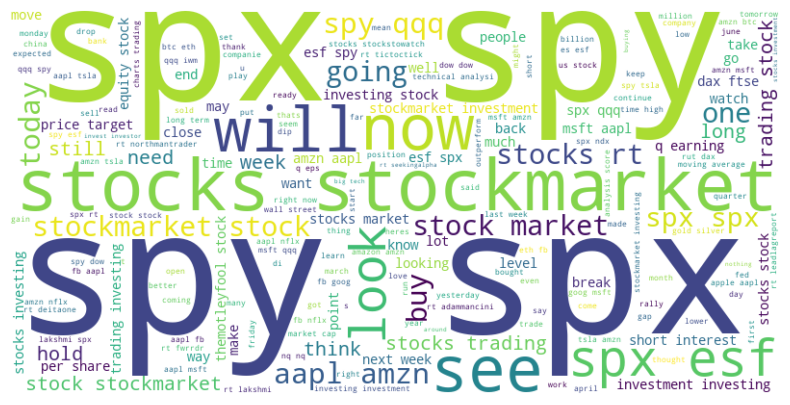

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convert the Series to a single string
text_string = " ".join(tweet_data['Text_Cleaned'].dropna())  # Drop NaN values if any

# Generate the word cloud
wordcloud_before_stopword = WordCloud(width=800, height=400, background_color='white').generate(text_string)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_before_stopword, interpolation='bilinear')
plt.axis("off")  # Hide axes
plt.show()


In [14]:
from nltk.corpus import stopwords

# General English stop words
general_stop_words = set(stopwords.words('english'))

# Define custom stopwords
custom_stopwords = set([
    'SP500', 'S&P', '500', 'index', 'u', 'us','trade', 'markets', 'amp','stockmarket', 'stock', 'market', 'stocks',
    'trading', 'finance', 'investing', 'investor', 'business',
    "billion", 'price', 'StockMarket', 'share',
    'RT', 'http','dollar','dollars', 'percent', 'https', 'www', 'bit.ly', '@username', '#finance',
    'breaking', 'update', 'today', 'yesterday', 'tomorrow',  "aapl", "msft", "amzn", "tsla", "googl", "meta", "nvda", "brk.b", "jnj", "pg", 
    "v", "unh", "hd", "ma", "pep", "bac", "xom", "ko", "abbv", "avgo", "cost", 
    "mcd", "csco", "pfe", "cvx", "adbe", "mrk", "nflx", "dis", "intc", "wmt", 
    "tmo", "orcl", "crm", "nke", "wfc", "acn", "lin", "mdt", "txn", "dhr", "hon", 
    "lly", "vz", "schw", "amgn", "ibm", "t", "qcom", "sbux", "mmm", "gs", "rtx", 
    "ups", "low", "bmy", "cat", "spgi", "isrg", "c", "elv", "lmt", "mo", "bkng", 
    "adp", "amd", "de", "pm", "gild", "syk", "ge", "amt", "ms", "blk", "cci", 
    "cvs", "now", "intu", "ci", "zts", "eqix", "ice", "tgt", "mu", "fis", "ew", 
    "cb", "mmc", "apd", "cl", "so", "pgr", "duke", "pld", "aon", "fisv", "itw", 
    "stz", "regn", "adi", "hum", "exc", "pxd", "snps", "cop", "kdp", "kmb", "rop", 
    "etn", "aep", "eog", "mar", "atvi", "noc", "pru", "oxy", "orly", "d", "chrw", 
    "bax", "adm", "fdx", "aig", "dg", "tsco", "qqq", "fb", "spx", "spy","new", "day", "week", "rt"
])

# Combine general_stop_words with custom stopwords
combined_stopwords = general_stop_words.union(custom_stopwords)

# Remove stopwords function
def remove_stopwords(text, stopwords):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stopwords]
    return " ".join(filtered_words)

# Apply the function to the 'text' column
tweet_data['Text_Cleaned'] = tweet_data['Text_Cleaned'].apply(lambda x: remove_stopwords(x, combined_stopwords))


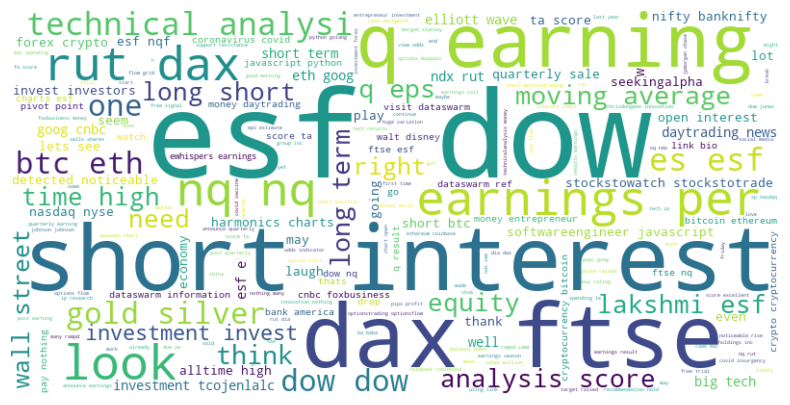

In [15]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convert the Series to a single string
text_string = " ".join(tweet_data['Text_Cleaned'].dropna())  # Drop NaN values if any

# Generate the word cloud
wordcloud_after_stopword = WordCloud(width=800, height=400, background_color='white').generate(text_string)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_after_stopword, interpolation='bilinear')
plt.axis("off")  # Hide axes
plt.show()


In [16]:
tweet_data.to_csv('/Users/shokoufehnaseri/Library/CloudStorage/OneDrive-Personal/Master-Thesis/Dataset/processed/cleaned_tweets_remaining.csv', index=False)
